# PointDiT demo -- run on any image directory, papermill-parameterized

Reuses the repo's own `main.py --evaluate_gen --eval_wild_images` entry point (the exact
same code path `scripts/demo_l_512.sh` calls) via subprocess, rather than re-deriving the
model-loading/inference logic here -- this notebook is a parameterized *driver*, not a
reimplementation. Requires `pretrained/pointditl-512-mixdata-nodinov3-240c1a4f.pth` and
`pretrained/dinov3/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth` to already exist (see
scripts/convert_hf_dinov3_to_hub.py if you need to (re)build the DINOv3 weights from an
ungated HF mirror).

In [1]:
import os
import subprocess
import sys
from pathlib import Path

In [2]:
# Directory of .jpg/.png images to run PointDiT on (recursive). Papermill overrides this.
image_dir = "assets/demo"
checkpoint = "pretrained/pointditl-512-mixdata-nodinov3-240c1a4f.pth"
img_size = 512
num_sampling_steps = 3
repo_root = str(Path(__file__).resolve().parent) if "__file__" in dir() else os.getcwd()

In [3]:
# Parameters
image_dir = "assets/test_image2"


In [4]:
os.chdir(repo_root)
print("repo_root:", repo_root)
print("image_dir:", image_dir)
assert Path(image_dir).is_dir(), f"image_dir does not exist: {image_dir}"
images = sorted([p for p in Path(image_dir).rglob("*") if p.suffix.lower() in (".jpg", ".jpeg", ".png")])
print(f"found {len(images)} image(s):", [str(p) for p in images])
assert images, f"no .jpg/.png files found under {image_dir}"

repo_root: /home/kaiser/projects/pointdit
image_dir: assets/test_image2
found 1 image(s): ['assets/test_image2/image_7.png']


In [5]:
env = os.environ.copy()
env["DINOV3_WEIGHTS_DIR"] = env.get("DINOV3_WEIGHTS_DIR", "pretrained/dinov3")

cmd = [
    sys.executable, "main.py",
    "--model", "PointDiT-L/16", "--feature_embedding_type", "dinov3_vitl16", "--proj_dropout", "0.0",
    "--evaluate_gen", "--eval_wild_images",
    "--eval_wild_images_dir", image_dir,
    "--img_size", str(img_size), "--num_sampling_steps", str(num_sampling_steps),
    "--pretrained", checkpoint,
]
print("running:", " ".join(cmd))
result = subprocess.run(cmd, cwd=repo_root, env=env, capture_output=True, text=True)
print(result.stdout[-4000:])
if result.returncode != 0:
    print(result.stderr[-4000:])
assert result.returncode == 0, f"main.py exited with code {result.returncode}"

running: /home/kaiser/.conda/envs/pointdit/bin/python main.py --model PointDiT-L/16 --feature_embedding_type dinov3_vitl16 --proj_dropout 0.0 --evaluate_gen --eval_wild_images --eval_wild_images_dir assets/test_image2 --img_size 512 --num_sampling_steps 3 --pretrained pretrained/pointditl-512-mixdata-nodinov3-240c1a4f.pth


[Warning] full-frame wild inference requires batch_size=1, overriding batch_size=128 to 1
[WildImagesDataset] Found 1 images in assets/test_image2
Test dataset: WildImagesDataset(test_image2, 1 images)
Loaded pretrained DINOv3 vitl16 from pretrained/dinov3/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth
Number of trainable parameters: 463.06M
Number of non-trainable parameters: 308.40M
resume pretrained ema
Load pretrained model from pretrained/pointditl-512-mixdata-nodinov3-240c1a4f.pth
Save to: /home/kaiser/projects/pointdit/generation/pretrained-pointditl-512-mixdata-nodinov3-240c1a4f/test_image2
Switch to ema
Generation step 0/1
Switch back from ema
Done!



## Real output check -- actually look at the result, don't just trust the exit code

In [6]:
ckpt_tag = Path(checkpoint).stem
out_dir = Path("generation") / f"pretrained-{ckpt_tag}" / Path(image_dir).name
print("output dir:", out_dir)
depth_pngs = sorted(out_dir.glob("*_depth.png"))
ply_files = sorted(out_dir.glob("*_pointcloud.ply"))
print(f"{len(depth_pngs)} depth PNG(s), {len(ply_files)} point-cloud PLY(s)")
assert depth_pngs and ply_files, f"expected outputs not found in {out_dir}"

output dir: generation/pretrained-pointditl-512-mixdata-nodinov3-240c1a4f/test_image2
1 depth PNG(s), 1 point-cloud PLY(s)


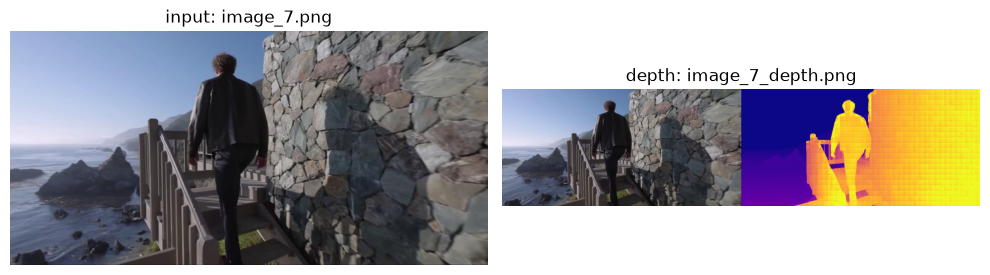

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(len(depth_pngs), 2, figsize=(10, 5 * len(depth_pngs)), squeeze=False)
for i, depth_png in enumerate(depth_pngs):
    src_img = images[i] if i < len(images) else None
    if src_img is not None:
        axes[i][0].imshow(Image.open(src_img))
        axes[i][0].set_title(f"input: {src_img.name}")
        axes[i][0].axis("off")
    axes[i][1].imshow(Image.open(depth_png))
    axes[i][1].set_title(f"depth: {depth_png.name}")
    axes[i][1].axis("off")
plt.tight_layout()
plt.show()

In [8]:
import trimesh

for ply in ply_files:
    mesh = trimesh.load(ply)
    n_points = len(mesh.vertices) if hasattr(mesh, "vertices") else "?"
    print(f"{ply.name}: {n_points} points, bbox {mesh.bounds.tolist() if hasattr(mesh, 'bounds') else 'n/a'}")

image_7_pointcloud.ply: 187965 points, bbox [[-1.5078125, -0.109375, -2.875], [0.361328125, 0.87890625, 0.93359375]]
